# Predictive Modeling in Marketing Analytics
## Predicting Campaign Conversion with Regularized Logistic Regression

**Author:** Albert Kabore, PhD student in AI

### Introduction
Predicting conversion is a useful marketing problem, but a model can appear accurate simply by predicting that nobody will buy. This is a particular concern here: only about 2.52% of the supplied records have a positive conversion outcome. I therefore examine both the models' ability to rank likely converters and the precision-recall trade-off at a chosen decision threshold.

The project compares logistic regression with L1 and L2 regularization against an unregularized model and a constant-probability baseline. My main question is whether regularization produces a simpler model while retaining useful predictive performance. I assess that question through cross-validation, test-set metrics, and the fitted coefficients, rather than assuming that a penalty must improve the results.

The analysis uses the supplied `marketing_AB.csv`; no observations or customer attributes have been invented. It addresses the marketing-prediction objective in the assignment. However, the file contains campaign exposure rather than demographics or prior purchases, so it does not fully meet the stated data-collection requirement. Section 2 explains this limitation and what remains unknown about the source.

**Research questions.** I ask whether L1 or L2 improves discrimination and probability prediction relative to unregularized logistic regression, how much coefficient sparsity can be obtained, and how threshold choice changes precision and recall. These questions separate the predictive objective from the question of whether advertising causes purchases.

### 1.1 Import libraries and configure the analysis

In [1]:
import json
import time
import warnings
from pathlib import Path

from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss, confusion_matrix,
    f1_score, log_loss, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from IPython.display import display
import hashlib
import sys
from importlib.metadata import version
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RANDOM_STATE = 42
N_JOBS = 5  # one worker per CV fold
DATA_PATH = Path("marketing_AB.csv")
FIG_DIR, OUT_DIR = Path("figures"), Path("results")
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# Consistent chart palette (accessibility not independently validated)
C_L1, C_L2, C_OLS, C_BASE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "axes.titleweight": "bold",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK2, "ytick.color": INK2, "font.size": 10, "lines.linewidth": 2,
})

def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")
    plt.show()

print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")
print(f"Python {sys.version.split()[0]} | executable: {sys.executable}")
print("Dataset SHA-256:", hashlib.sha256(DATA_PATH.read_bytes()).hexdigest())

pandas 2.3.3 | numpy 2.3.4 | scikit-learn 1.7.2
Python 3.11.0 | executable: C:\Users\alber\AppData\Local\Programs\Python\Python311\python.exe
Dataset SHA-256: de6ce8def1a6559e9e5ab364fce07cfe2e84f02dd407c3586eea55743c7e17f2


## 2. Data Collection

**Source (faviovaz, n.d.).** *Marketing A/B Testing* dataset, published on Kaggle by user *faviovaz* (https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing), file `marketing_AB.csv` (the file in this repository). The publisher describes user-level advertising/PSA records. The local audit verifies unique user identifiers.

| Column | Type | Description |
|---|---|---|
| `user id` | int | Unique user identifier |
| `test group` | categorical | `ad` = saw product advertisements; `psa` = saw a public-service announcement (control) |
| `converted` | bool | **Target** — whether the user bought the product |
| `total ads` | int | Number of ads the user saw (purchase-funnel exposure / engagement history) |
| `most ads day` | categorical | Day of week on which the user saw the most ads |
| `most ads hour` | int 0–23 | Hour of day at which the user saw the most ads |

**Fit to the assignment.** The instructions ask for customer demographics, purchase history, and other relevant features. This file has neither demographics nor a history of purchases. The `converted` outcome is not purchase history, and `total ads` measures advertising exposure. I have not inferred or fabricated the missing attributes. Completing this requirement would require a suitable documented dataset, or the instructor's explicit acceptance of this narrower scope.

**Source limitations.** The Kaggle listing can be located, but I have not independently established the original organization, collection dates, assignment protocol, or whether the records are empirical or synthetic. The local file has not been matched byte-for-byte to a hosted version. I therefore treat it as a supplied dataset for a modeling exercise, not as independently verified evidence from a real experiment. The setup cell records its SHA-256 hash so the analyzed file can be identified.

### 2.1 Load and preview the dataset

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Shape: 588,101 rows x 7 columns


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


### 2.2 Inspect column types and non-missing counts

In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


### 2.3 Audit missing values, identifiers, and numeric distributions

In [4]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_%": raw.isna().mean() * 100,
    "unique": raw.nunique(),
})
display(audit)
print("Duplicate rows       :", raw.duplicated().sum())
print("Duplicate user ids   :", raw["user id"].duplicated().sum())
print("'Unnamed: 0' == index:", (raw["Unnamed: 0"] == raw.index).all())
raw.describe().T

,dtype,missing,missing_%,unique
Unnamed: 0,int64,0,0.0000,588101
user id,int64,0,0.0000,588101
test group,object,0,0.0000,2
converted,bool,0,0.0000,2
total ads,int64,0,0.0000,807
most ads day,object,0,0.0000,7
most ads hour,int64,0,0.0000,24


Duplicate rows       : 0
Duplicate user ids   : 0
'Unnamed: 0' == index: True


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,"588,101.0000","294,050.0000","169,770.2797",0.0000,"147,025.0000","294,050.0000","441,075.0000","588,100.0000"
user id,"588,101.0000","1,310,692.2158","202,225.9831","900,000.0000","1,143,190.0000","1,313,725.0000","1,484,088.0000","1,654,483.0000"
total ads,"588,101.0000",24.8209,43.7152,1.0000,4.0000,13.0000,27.0000,"2,065.0000"
most ads hour,"588,101.0000",14.4691,4.8346,0.0000,11.0000,14.0000,18.0000,23.0000


**Data-quality findings.** The audit finds no missing values, duplicate rows, or duplicate user identifiers. `Unnamed: 0` matches the saved row index. I exclude both index and user ID from the predictors because they are identifiers rather than substantive customer characteristics. The exposure count is highly skewed, with a median of 13 and a maximum of 2,065. This motivates considering a logarithmic term alongside the raw count.

## 3. Exploratory Data Analysis

### 3.1 Describe class balance and observed group differences

In [5]:
df = raw.drop(columns=["Unnamed: 0", "user id"]).rename(columns=lambda c: c.replace(" ", "_"))
df["converted"] = df["converted"].astype(int)

base_rate = df["converted"].mean()
print(f"Overall conversion rate: {base_rate:.4%}  ({df['converted'].sum():,} of {len(df):,} users)")
print(f"Class imbalance       : 1 converter per {1/base_rate:.0f} users\n")

grp = df.groupby("test_group")["converted"].agg(users="size", conversions="sum", rate="mean")
display(grp)
lift = grp.loc["ad", "rate"] / grp.loc["psa", "rate"] - 1
print(f"Relative lift of ads vs PSA: {lift:.1%}")

Overall conversion rate: 2.5239%  (14,843 of 588,101 users)
Class imbalance       : 1 converter per 40 users



,users,conversions,rate
test_group,,,
ad,564577,14423,0.0255
psa,23524,420,0.0179


Relative lift of ads vs PSA: 43.1%


### 3.2 Examine conversion rates by day and hour

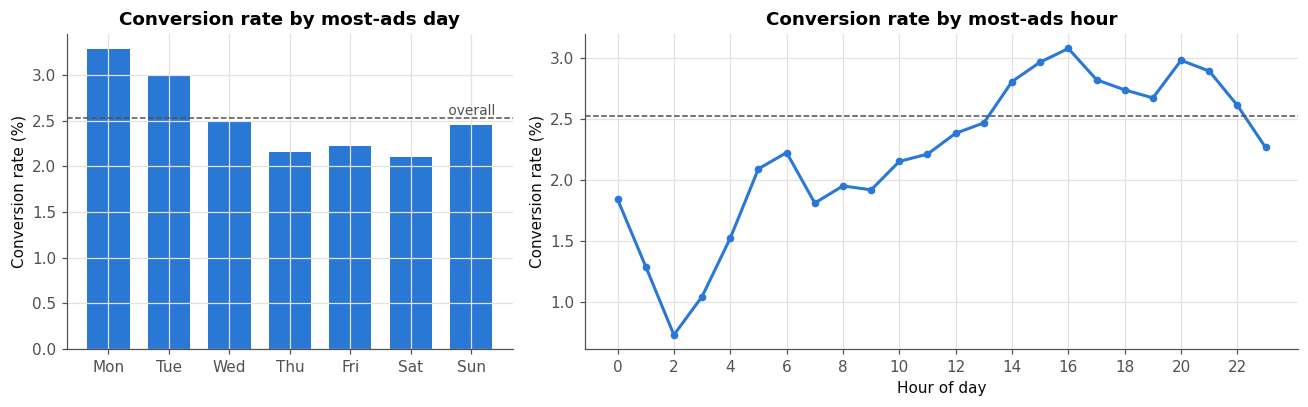

In [6]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_day = df.groupby("most_ads_day")["converted"].mean().reindex(day_order)
by_hour = df.groupby("most_ads_hour")["converted"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 1.6]})
axes[0].bar(by_day.index.str[:3], by_day * 100, color=C_L1, width=0.7)
axes[0].axhline(base_rate * 100, color=INK2, ls="--", lw=1)
axes[0].text(6.4, base_rate * 100, " overall", va="bottom", ha="right", color=INK2, fontsize=9)
axes[0].set(title="Conversion rate by most-ads day", ylabel="Conversion rate (%)")
axes[1].plot(by_hour.index, by_hour * 100, color=C_L1, marker="o", ms=4)
axes[1].axhline(base_rate * 100, color=INK2, ls="--", lw=1)
axes[1].set(title="Conversion rate by most-ads hour", xlabel="Hour of day", ylabel="Conversion rate (%)",
            xticks=range(0, 24, 2))
fig.tight_layout()
savefig(fig, "eda_day_hour")

### 3.3 Examine exposure distribution and conversion rates

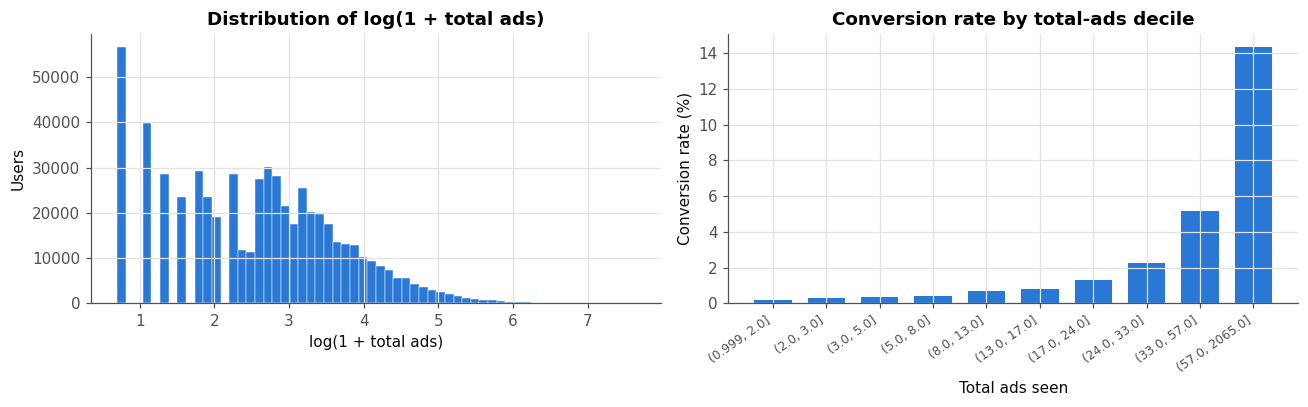

In [7]:
df["ads_bucket"] = pd.qcut(df["total_ads"], q=10, duplicates="drop")
by_ads = df.groupby("ads_bucket", observed=True)["converted"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(np.log1p(df["total_ads"]), bins=60, color=C_L1, edgecolor="white", linewidth=0.3)
axes[0].set(title="Distribution of log(1 + total ads)", xlabel="log(1 + total ads)", ylabel="Users")
axes[1].bar(range(len(by_ads)), by_ads * 100, color=C_L1, width=0.7)
axes[1].set_xticks(range(len(by_ads)), [str(i) for i in by_ads.index], rotation=35, ha="right", fontsize=8)
axes[1].set(title="Conversion rate by total-ads decile", xlabel="Total ads seen", ylabel="Conversion rate (%)")
fig.tight_layout()
savefig(fig, "eda_total_ads")
df = df.drop(columns="ads_bucket")

### Observations from the supplied data

- **Conversion is uncommon.** The file contains 14,843 conversions among 588,101 records, a rate of 2.52%. A classifier that predicts no conversions would be about 97.5% accurate, so accuracy alone would give an incomplete account of performance.
- **Exposure and conversion are associated.** The observed conversion rate increases from about 0.19% in the lowest exposure group (1-2 ads) to 14.3% in the highest (58 or more ads). These quantile-based groups are not necessarily equal in size because many records share the same exposure count.
- **Timing groups differ.** Monday and Tuesday have conversion rates of about 3.28% and 2.98%, compared with 2.11% on Saturday. The rate at 2 a.m. is approximately 0.73%. These comparisons describe the recorded groups; they do not show that rescheduling ads would change conversion.
- **The ad group has a higher observed rate.** Conversion is approximately 2.55% in the ad group and 1.79% in the PSA group. The difference is about 0.769 percentage points, or 43.1% relative to the PSA rate. A causal interpretation would require evidence about how users were assigned and how outcomes were measured.

## 4. Preprocessing & Feature Engineering

| Step | Treatment | Rationale |
|---|---|---|
| Identifiers | Drop `Unnamed: 0`, `user id` | Exclude identifiers to reduce spurious fitting |
| Missing values | `SimpleImputer` — median (numeric), most-frequent (categorical) inside the pipeline | The supplied file has no missing values. Imputers are fitted inside CV; future raw inputs still require schema and missing-category validation before feature engineering |
| Skew | `log_total_ads = log1p(total_ads)` | Compresses a 1–2,065 range; permits a nonlinear association with exposure |
| Treatment flag | `is_ad = 1` if `test_group == "ad"` | Binary encoding of the A/B arm |
| Raw `total_ads` | Kept alongside its log | Deliberately correlated pair → shows how Lasso vs Ridge handle redundant features |
| Categoricals | One-hot encode `most_ads_day` (7 levels) and `most_ads_hour` (24 levels, treated as categorical because the hour effect is non-monotonic). **Regularized models keep all levels** (full one-hot); the **unregularized baseline drops the first level** (reference coding) | A linear model needs numeric inputs. Without a penalty, a full set of dummies is perfectly collinear with the intercept, so reference coding is used here. Full encoding avoids choosing a reference category for the penalty. L2 can yield unique penalized coefficients; L1 coefficient uniqueness is not guaranteed with redundant columns. Interpret category contrasts rather than individual dummy coefficients. |
| Scaling | `StandardScaler` on the numeric features and, for the regularized models, on the one-hot dummies too  | **Penalty scaling.** The L1/L2 penalty acts on raw coefficient size, so standardization is used here to define the relative penalty weighting. Standardizing the dummies also centres them, which changes the penalty weighting across category frequencies. Standardization does not make coefficients causal or establish variable importance. |

**Order of operations.** Identifiers are removed before fitting. The log exposure term and binary ad-group flag are deterministic row-wise transformations; they do not estimate population parameters. Fitted preprocessing is then carried out separately within each training fold. A scaler estimates the training mean and standard deviation and applies those same values to the validation fold. The same principle applies to imputation statistics and one-hot categories. This prevents fitted preprocessing from using validation records, although it does not undo the earlier use of the full dataset for exploratory feature decisions.

**Missing and unfamiliar inputs.** No values required imputation in the supplied CSV. Median and most-frequent imputers specify what would happen to missing transformed inputs, rather than implying that missing observations were found. The encoder ignores unfamiliar categories, which maps them to an all-zero indicator vector before scaling. That is a computational fallback, not evidence that predictions for new categories are reliable. In particular, raw missing hours must be handled before conversion to strings, and missing group labels must not silently become PSA assignments.

### 4.1 Construct the modeling features

In [8]:
def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    # Deterministic, row-wise feature engineering (no fitted state -> no leakage).
    out = pd.DataFrame(index=frame.index)
    out["total_ads"] = frame["total_ads"]
    out["log_total_ads"] = np.log1p(frame["total_ads"])
    out["is_ad"] = (frame["test_group"] == "ad").astype(int)
    out["most_ads_day"] = frame["most_ads_day"]
    out["most_ads_hour"] = frame["most_ads_hour"].astype(str).str.zfill(2)
    return out

NUM_FEATURES = ["total_ads", "log_total_ads", "is_ad"]
CAT_FEATURES = ["most_ads_day", "most_ads_hour"]

X = engineer_features(df)
y = df["converted"].to_numpy()
X.head()

,total_ads,log_total_ads,is_ad,most_ads_day,most_ads_hour
0,130,4.8752,1,Monday,20
1,93,4.5433,1,Tuesday,22
2,21,3.0910,1,Tuesday,18
3,355,5.8749,1,Tuesday,10
4,276,5.6240,1,Friday,14


### 4.2 Create the stratified training and test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train):,} rows | positive rate {y_train.mean():.4%}")
print(f"Test : {len(X_test):,} rows | positive rate {y_test.mean():.4%}")

Train: 470,480 rows | positive rate 2.5238%
Test : 117,621 rows | positive rate 2.5242%


### 4.3 Define imputation, encoding, and scaling pipelines

In [10]:
def make_preprocessor(drop: str | None = None) -> ColumnTransformer:
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop=drop, handle_unknown="ignore", sparse_output=False)),
        # Regularized models: standardize dummies so the penalty treats every column on the same scale
        ("scale", StandardScaler() if drop is None else "passthrough"),
    ])
    return ColumnTransformer(
        [("num", numeric, NUM_FEATURES), ("cat", categorical, CAT_FEATURES)],
        verbose_feature_names_out=False,
    )

FEATURE_NAMES = list(make_preprocessor().fit(X_train).get_feature_names_out())
N_REF = len(make_preprocessor(drop="first").fit(X_train).get_feature_names_out())
print(f"Regularized models: {len(FEATURE_NAMES)} features (full one-hot) | unregularized baseline: {N_REF} (reference coding)")
print(FEATURE_NAMES)

Regularized models: 34 features (full one-hot) | unregularized baseline: 32 (reference coding)
['total_ads', 'log_total_ads', 'is_ad', 'most_ads_day_Friday', 'most_ads_day_Monday', 'most_ads_day_Saturday', 'most_ads_day_Sunday', 'most_ads_day_Thursday', 'most_ads_day_Tuesday', 'most_ads_day_Wednesday', 'most_ads_hour_00', 'most_ads_hour_01', 'most_ads_hour_02', 'most_ads_hour_03', 'most_ads_hour_04', 'most_ads_hour_05', 'most_ads_hour_06', 'most_ads_hour_07', 'most_ads_hour_08', 'most_ads_hour_09', 'most_ads_hour_10', 'most_ads_hour_11', 'most_ads_hour_12', 'most_ads_hour_13', 'most_ads_hour_14', 'most_ads_hour_15', 'most_ads_hour_16', 'most_ads_hour_17', 'most_ads_hour_18', 'most_ads_hour_19', 'most_ads_hour_20', 'most_ads_hour_21', 'most_ads_hour_22', 'most_ads_hour_23']


## 5. Model Selection & Regularization

I use logistic regression because the target is binary and the fitted model provides both probability estimates and a coefficient-based representation of its predictions. These probabilities are not assumed to be calibrated; that would require a separate assessment.

Regularization adds a coefficient penalty to the logistic loss. An L1 penalty uses the sum of absolute coefficient values and can set coefficients exactly to zero. An L2 penalty uses squared coefficient values and generally shrinks coefficients without producing a sparse solution. In the scikit-learn implementation used here, smaller `C` means stronger regularization (scikit-learn, n.d.-b).

| Model | Purpose |
|---|---|
| Constant-probability baseline | Predict the training conversion rate for every record; at 0.50, predict the majority class |
| Unregularized logistic regression | Provide a comparison without a coefficient penalty |
| L2-regularized logistic regression (Ridge) | Tune the amount of shrinkage by cross-validation |
| L1-regularized logistic regression (Lasso) | Evaluate shrinkage and selection of encoded predictors |
| L1 with the one-standard-error rule | Select the smallest eligible `C` for a sparser candidate |

Lasso and Ridge refer here to penalties within logistic regression, not to least-squares regression estimators. The L1 models use `liblinear`; L2 and unregularized models use `lbfgs`. `liblinear` also penalizes its synthetic intercept feature. Setting `intercept_scaling=100` reduces that penalty but does not remove it (scikit-learn, n.d.-b). Because solver, intercept treatment, and categorical encoding differ, this comparison does not isolate the penalty as the only implementation difference.

**Statistical formulation.** If z is the intercept plus the weighted sum of the transformed inputs, logistic regression estimates conversion probability as 1 / (1 + exp(-z)). Training minimizes binary cross-entropy with an optional coefficient penalty. L1 penalizes the sum of absolute weights; L2 penalizes half the sum of squared weights in the summed-loss convention used to describe this comparison. A penalty can reduce sensitivity to the training sample, but it also introduces shrinkage bias. Its usefulness must therefore be judged using validation results rather than presumed from the model name.

**Implementation choices.** The analysis uses scikit-learn (Pedregosa et al., 2011). No oversampling, synthetic examples, or class weights are used. Instead, stratification preserves the rare positive class in the splits, and training-only threshold selection addresses the all-negative predictions at 0.50. The L1 iteration limit is 3,000, the L2 limit is 2,000, and the unregularized limit is 5,000. These are solver limits, not the number of iterations necessarily taken.

### 5.1 Define the logistic-regression candidates

In [11]:
def make_model(penalty: str | None, C: float = 1.0) -> Pipeline:
    if penalty == "l1":
        clf = LogisticRegression(penalty="l1", solver="liblinear", C=C, intercept_scaling=100,
                                 max_iter=3000, random_state=RANDOM_STATE)
    elif penalty == "l2":
        clf = LogisticRegression(penalty="l2", solver="lbfgs", C=C, max_iter=2000)
    else:
        clf = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000)
    pre = make_preprocessor(drop="first" if penalty is None else None)
    return Pipeline([("pre", pre), ("clf", clf)])

## 6. Training & Hyperparameter Tuning

I use an 80/20 stratified split with `random_state=42`, giving 470,480 training records and 117,621 test records. Hyperparameters are selected using five shuffled, stratified folds within the training set. Each fold refits the imputer, encoder, and scaler as part of the model pipeline.

The search evaluates 11 logarithmically spaced `C` values from 0.0001 to 10 for each penalty. Mean validation ROC-AUC determines the selected model; validation log-loss is also recorded. After selection, each candidate is fitted on the full training set.

For the sparse L1 candidate, I use the smallest `C` whose mean validation AUC is no more than one estimated standard error below the best mean. The estimate is the best candidate's fold standard deviation divided by the square root of five. This is a selection heuristic, not a test that the candidates are statistically equivalent.

**Limits of the validation design.** The exploratory plots use the full dataset and informed feature choices. Although test labels are excluded from model fitting and threshold selection, the test set was not isolated from all analytical decisions. In addition, hyperparameter selection and out-of-fold threshold tuning reuse the same training folds rather than using nested cross-validation. I therefore interpret the reported scores as exploratory internal validation. Performance on a future campaign, uncertainty in score differences, and feature-selection stability remain to be assessed.

**Selection and reproducibility.** Each penalty's search evaluates 11 candidates over five folds, or 55 candidate-fold fits, followed by refitting the selected candidate. ROC-AUC is the refit criterion; log-loss does not determine which `C` wins. Threshold tuning subsequently generates out-of-fold probabilities for each fixed logistic candidate, computes precision and recall over candidate thresholds, and selects the threshold with the largest training F1. Test labels are used only for reported test metrics at this stage. The earlier full-data exploration and reuse of folds remain the qualifications discussed above.

The same random seed is used for the stratified split, shuffled folds, and L1 solver. Package versions and the dataset hash are recorded with the results. These records support reproduction of the present run; they do not guarantee identical floating-point coefficients across every operating system or software version.

### 6.1 Tune regularization strength with stratified cross-validation

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
C_GRID = np.logspace(-4, 1, 11)
scoring = {"roc_auc": "roc_auc", "neg_log_loss": "neg_log_loss"}

searches = {}
for penalty in ["l1", "l2"]:
    t0 = time.perf_counter()
    gs = GridSearchCV(make_model(penalty), {"clf__C": C_GRID}, cv=cv, scoring=scoring,
                      refit="roc_auc", n_jobs=N_JOBS, return_train_score=True)
    gs.fit(X_train, y_train)
    searches[penalty] = gs
    print(f"{penalty.upper()}: best C = {gs.best_params_['clf__C']:.4g} | "
          f"CV ROC-AUC = {gs.best_score_:.4f} | {time.perf_counter() - t0:.0f}s")

L1: best C = 0.03162 | CV ROC-AUC = 0.8570 | 339s


L2: best C = 0.03162 | CV ROC-AUC = 0.8570 | 84s


### 6.2 Summarize validation scores and apply the one-standard-error rule

In [13]:
def cv_table(gs):
    r = gs.cv_results_
    return pd.DataFrame({
        "C": r["param_clf__C"].astype(float),
        "cv_auc_mean": r["mean_test_roc_auc"], "cv_auc_std": r["std_test_roc_auc"],
        "train_auc_mean": r["mean_train_roc_auc"],
        "cv_logloss_mean": -r["mean_test_neg_log_loss"],
    })

cv_l1, cv_l2 = cv_table(searches["l1"]), cv_table(searches["l2"])

# One-standard-error rule for Lasso: the smallest C (strongest penalty) whose CV AUC is within
# one standard error of the best mean CV AUC.
best = cv_l1.loc[cv_l1["cv_auc_mean"].idxmax()]
se = best["cv_auc_std"] / np.sqrt(cv.get_n_splits())
C_1SE = cv_l1.loc[cv_l1["cv_auc_mean"] >= best["cv_auc_mean"] - se, "C"].min()
BEST_C = {"l1": searches["l1"].best_params_["clf__C"], "l2": searches["l2"].best_params_["clf__C"], "l1_1se": C_1SE}
print(f"Lasso best C = {BEST_C['l1']:.4g}; 1-SE threshold AUC = {best['cv_auc_mean'] - se:.4f} -> C_1SE = {C_1SE:.4g}")
print(f"Ridge best C = {BEST_C['l2']:.4g}")

display(cv_l1.merge(cv_l2, on="C", suffixes=("_L1", "_L2")).round(4))

Lasso best C = 0.03162; 1-SE threshold AUC = 0.8556 -> C_1SE = 0.003162
Ridge best C = 0.03162


,C,cv_auc_mean_L1,cv_auc_std_L1,train_auc_mean_L1,cv_logloss_mean_L1,cv_auc_mean_L2,cv_auc_std_L2,train_auc_mean_L2,cv_logloss_mean_L2
0,0.0001,0.8534,0.0036,0.8534,0.1105,0.8561,0.0032,0.8565,0.1013
1,0.0003,0.8534,0.0036,0.8534,0.0978,0.8562,0.0032,0.8567,0.0974
2,0.0010,0.8537,0.0036,0.8537,0.0958,0.8566,0.0032,0.8571,0.0949
3,0.0032,0.8559,0.0034,0.8561,0.0943,0.8569,0.0032,0.8574,0.0941
4,0.0100,0.8570,0.0033,0.8573,0.0939,0.8570,0.0032,0.8575,0.0939
5,0.0316,0.8570,0.0033,0.8575,0.0939,0.8570,0.0032,0.8575,0.0939
6,0.1000,0.8570,0.0032,0.8575,0.0939,0.8570,0.0032,0.8575,0.0939
7,0.3162,0.8570,0.0032,0.8575,0.0939,0.8570,0.0032,0.8575,0.0939
8,1.0000,0.8570,0.0032,0.8574,0.0939,0.8570,0.0032,0.8575,0.0939
9,3.1623,0.8570,0.0032,0.8574,0.0939,0.8570,0.0032,0.8575,0.0939


### 6.3 Visualize validation performance across the penalty grid

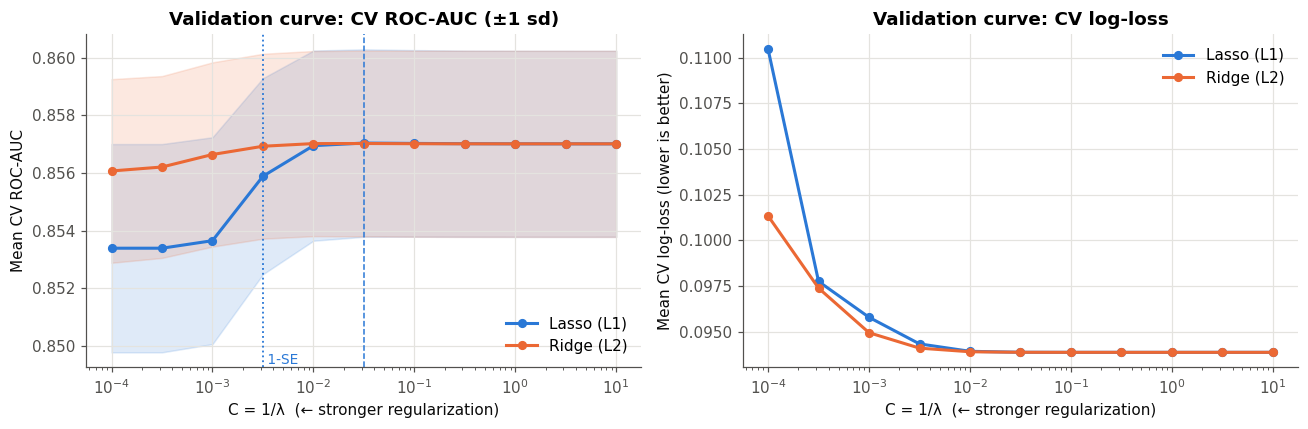

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for tbl, color, label in [(cv_l1, C_L1, "Lasso (L1)"), (cv_l2, C_L2, "Ridge (L2)")]:
    axes[0].plot(tbl["C"], tbl["cv_auc_mean"], marker="o", ms=5, color=color, label=label)
    axes[0].fill_between(tbl["C"], tbl["cv_auc_mean"] - tbl["cv_auc_std"],
                         tbl["cv_auc_mean"] + tbl["cv_auc_std"], color=color, alpha=0.15)
    axes[1].plot(tbl["C"], tbl["cv_logloss_mean"], marker="o", ms=5, color=color, label=label)
axes[0].axvline(BEST_C["l1"], color=C_L1, ls="--", lw=1)
axes[0].axvline(C_1SE, color=C_L1, ls=":", lw=1.2)
axes[0].text(C_1SE, axes[0].get_ylim()[0], " 1-SE", color=C_L1, fontsize=9, va="bottom")
axes[0].set(xscale="log", title="Validation curve: CV ROC-AUC (±1 sd)", xlabel="C = 1/λ  (← stronger regularization)",
            ylabel="Mean CV ROC-AUC")
axes[1].set(xscale="log", title="Validation curve: CV log-loss", xlabel="C = 1/λ  (← stronger regularization)",
            ylabel="Mean CV log-loss (lower is better)")
for ax in axes:
    ax.legend(frameon=False)
fig.tight_layout()
savefig(fig, "cv_validation_curves")

**Observations from cross-validation**

- Both penalties select `C` of approximately 0.0316, with mean validation ROC-AUC near 0.857.
- The one-standard-error rule selects approximately 0.00316 for L1, giving a stronger penalty than the best-score candidate.
- The plotted scores vary little across the weaker penalties. This supports examining a simpler candidate, but it does not establish that regularization has no effect or that the models will perform equally on new data.
- The shaded bands show fold standard deviations. They are not confidence intervals for differences between models.

### 6.4 Fit the final candidates on the training set

In [15]:
models = {
    "Unregularized LR": make_model(None),
    "Ridge (L2)": make_model("l2", BEST_C["l2"]),
    "Lasso (L1)": make_model("l1", BEST_C["l1"]),
    "Lasso (L1, 1-SE)": make_model("l1", BEST_C["l1_1se"]),
}
for name, m in models.items():
    m.fit(X_train, y_train)
models["Majority baseline"] = DummyClassifier(strategy="prior").fit(X_train, y_train)

for name, m in models.items():
    if name == "Majority baseline":
        continue
    coefs = m.named_steps["clf"].coef_.ravel()
    # (unregularized model uses reference coding, hence fewer columns)
    print(f"{name:<18} non-zero coefficients: {(np.abs(coefs) > 1e-8).sum():>2} / {len(coefs)}")

Unregularized LR   non-zero coefficients: 32 / 32
Ridge (L2)         non-zero coefficients: 34 / 34
Lasso (L1)         non-zero coefficients: 32 / 34
Lasso (L1, 1-SE)   non-zero coefficients: 22 / 34


## 7. Regularization Paths

The following plots show how the fitted coefficients change across the specified penalty grid. They make L1's sparsity visible and allow comparison with L2 shrinkage. The order in which a coefficient becomes nonzero depends on scaling, correlated predictors, and the fitted sample; I do not treat it as an independent ranking of feature importance.

### 7.1 Estimate coefficient paths across regularization strengths

In [16]:
PATH_C = np.logspace(-4, 1, 21)
Xt_train = make_preprocessor().fit(X_train).transform(X_train)   # scaled design matrix

def _fit_coef(penalty, C):
    return make_model(penalty, C).named_steps["clf"].fit(Xt_train, y_train).coef_.ravel()

def coef_path(penalty):
    rows = Parallel(n_jobs=N_JOBS)(delayed(_fit_coef)(penalty, C) for C in PATH_C)
    return pd.DataFrame(rows, index=PATH_C, columns=FEATURE_NAMES)

path_l1, path_l2 = coef_path("l1"), coef_path("l2")
nonzero_l1 = (path_l1.abs() > 1e-8).sum(axis=1)

### 7.2 Plot shrinkage paths and L1 coefficient selection

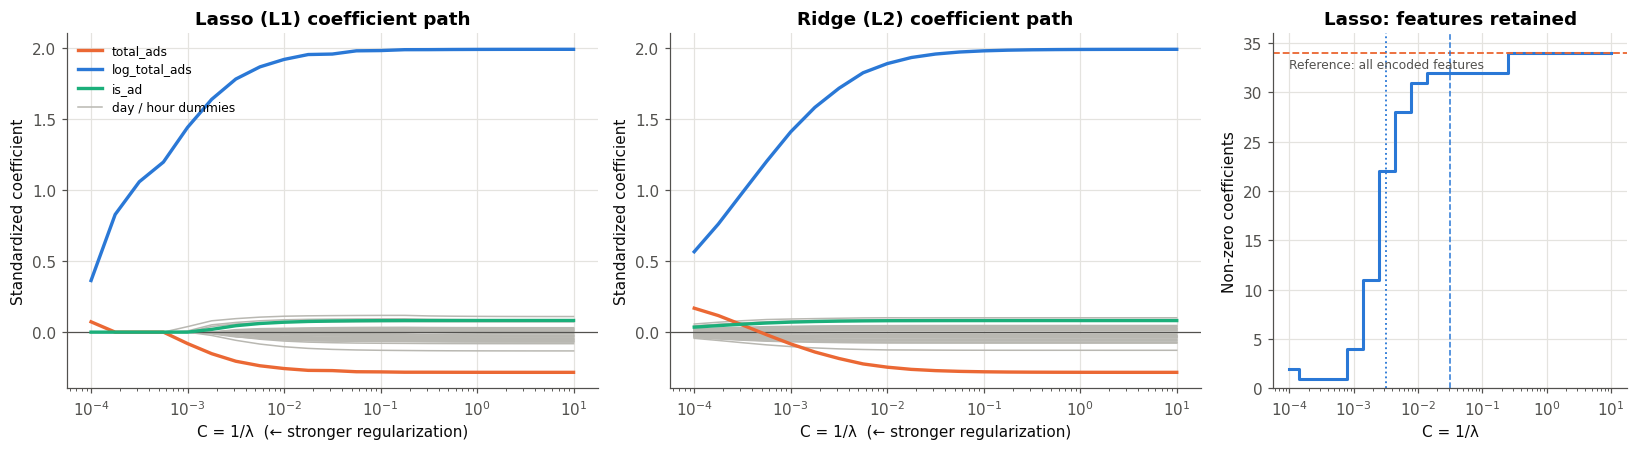

Order in which Lasso admits features as the penalty weakens:
total_ads               0.0001
log_total_ads           0.0001
most_ads_day_Monday     0.0010
most_ads_day_Tuesday    0.0010
most_ads_day_Friday     0.0018
most_ads_day_Saturday   0.0018
most_ads_hour_01        0.0018
is_ad                   0.0018
most_ads_hour_02        0.0018
most_ads_hour_07        0.0018


In [17]:
highlight = {"log_total_ads": C_L1, "total_ads": C_L2, "is_ad": C_OLS}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), gridspec_kw={"width_ratios": [1.2, 1.2, 0.8]})
for ax, path, title in [(axes[0], path_l1, "Lasso (L1) coefficient path"), (axes[1], path_l2, "Ridge (L2) coefficient path")]:
    for col in path.columns:
        if col in highlight:
            ax.plot(path.index, path[col], color=highlight[col], lw=2.2, label=col, zorder=3)
        else:
            ax.plot(path.index, path[col], color="#b9b8b2", lw=1, zorder=2)
    ax.axhline(0, color=INK2, lw=0.8)
    ax.set(xscale="log", title=title, xlabel="C = 1/λ  (← stronger regularization)", ylabel="Standardized coefficient")
axes[0].plot([], [], color="#b9b8b2", lw=1, label="day / hour dummies")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
axes[2].step(PATH_C, nonzero_l1, where="mid", color=C_L1)
axes[2].axhline(len(FEATURE_NAMES), color=C_L2, ls="--", lw=1.2)
axes[2].text(PATH_C[0], len(FEATURE_NAMES) - 0.5, "Reference: all encoded features", color=INK2, fontsize=8, va="top")
axes[2].axvline(BEST_C["l1"], color=C_L1, ls="--", lw=1)
axes[2].axvline(BEST_C["l1_1se"], color=C_L1, ls=":", lw=1.2)
axes[2].set(xscale="log", title="Lasso: features retained", xlabel="C = 1/λ", ylabel="Non-zero coefficients",
            ylim=(0, len(FEATURE_NAMES) + 2))
fig.tight_layout()
savefig(fig, "regularization_paths")

print("Order in which Lasso admits features as the penalty weakens:")
entry = {c: path_l1.index[(path_l1[c].abs() > 1e-8).to_numpy()].min() for c in FEATURE_NAMES}
print(pd.Series(entry).sort_values().head(10).to_string())

## 8. Evaluation on the Held-out Test Set

I report several metrics because no single score captures both ranking quality and the consequences of a classification threshold.

- **ROC-AUC** measures discrimination across thresholds.
- **Average precision (AP)** summarizes precision-recall performance. It differs from trapezoidal precision-recall area (scikit-learn, n.d.-a). The saved field `pr_auc` contains AP, and a constant-score model has AP equal to test prevalence.
- **Accuracy, precision, recall, and F1** describe predictions at a specified threshold.
- **Log-loss and Brier score** assess probability predictions; neither alone establishes calibration.
- **Top-decile capture** measures the share of recorded converters among the highest-scored approximately 10% of test records. It measures retrospective ranking, not additional conversions caused by targeting.

For each logistic model, I select a threshold that maximizes F1 on out-of-fold training predictions and compare it with 0.50. The baseline is reported at 0.50 only. F1 is useful for this comparison, but a deployment threshold would need to reflect campaign costs, conversion value, and operational capacity.

**Why these metrics are complementary.** Precision is TP / (TP + FP), recall is TP / (TP + FN), and F1 is their harmonic mean. ROC-AUC measures ranking across positive-negative pairs, whereas precision-recall analysis makes the false-positive burden more visible when positive outcomes are uncommon (Saito & Rehmsmeier, 2015). AP is reported alongside ROC-AUC for that reason. Lower log-loss and Brier scores indicate better probability predictions under those scoring rules. A calibration plot would still be needed to examine whether stated probabilities match observed frequencies across risk groups.

### 8.1 Select classification thresholds from training predictions

In [18]:
def tune_threshold(model) -> float:
    oof = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=N_JOBS)[:, 1]
    prec, rec, thr = precision_recall_curve(y_train, oof)
    f1 = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
    return float(thr[np.nanargmax(f1[:-1])])

def top_decile(y_true, proba, frac=0.10):
    k = max(1, int(len(proba) * frac))
    if np.all(proba == proba[0]):
        # Expected capture under random tie-breaking; constant scores cannot rank users.
        return k / len(proba), 1.0
    top = np.argsort(-proba)[:k]
    capture = y_true[top].sum() / y_true.sum()
    return capture, capture / (k / len(proba))

thresholds = {name: tune_threshold(m) for name, m in models.items() if name != "Majority baseline"}
thresholds["Majority baseline"] = 0.5
pd.Series(thresholds, name="F1-optimal threshold (OOF)").to_frame()

,F1-optimal threshold (OOF)
Unregularized LR,0.1105
Ridge (L2),0.1069
Lasso (L1),0.1064
"Lasso (L1, 1-SE)",0.0956
Majority baseline,0.5000


### 8.2 Calculate test-set classification and probability metrics

In [19]:
rows, probas = [], {}
for name, m in models.items():
    p = m.predict_proba(X_test)[:, 1]
    probas[name] = p
    capture, lift_ = top_decile(y_test, p)
    operating_points = [("0.50", 0.5)] if name == "Majority baseline" else [("0.50", 0.5), ("F1-opt", thresholds[name])]
    for thr_label, thr in operating_points:
        pred = (p >= thr).astype(int)
        rows.append({
            "model": name, "threshold": thr_label, "thr_value": thr,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, p),
            "pr_auc": average_precision_score(y_test, p),
            "log_loss": log_loss(y_test, p),
            "brier": brier_score_loss(y_test, p),
            "top10_capture": capture, "top10_lift": lift_,
        })
results = pd.DataFrame(rows)
results.round(4)

,model,threshold,thr_value,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,brier,top10_capture,top10_lift
0,Unregularized LR,0.50,0.5000,0.9748,0.0000,0.0000,0.0000,0.8600,0.1420,0.0935,0.0227,0.5783,5.7831
1,Unregularized LR,F1-opt,0.1105,0.9378,0.1726,0.3860,0.2385,0.8600,0.1420,0.0935,0.0227,0.5783,5.7831
2,Ridge (L2),0.50,0.5000,0.9748,0.0000,0.0000,0.0000,0.8600,0.1422,0.0935,0.0227,0.5797,5.7966
3,Ridge (L2),F1-opt,0.1069,0.9359,0.1714,0.4015,0.2403,0.8600,0.1422,0.0935,0.0227,0.5797,5.7966
4,Lasso (L1),0.50,0.5000,0.9748,0.0000,0.0000,0.0000,0.8601,0.1420,0.0935,0.0227,0.5800,5.8000
5,Lasso (L1),F1-opt,0.1064,0.9355,0.1709,0.4042,0.2402,0.8601,0.1420,0.0935,0.0227,0.5800,5.8000
6,"Lasso (L1, 1-SE)",0.50,0.5000,0.9748,0.0000,0.0000,0.0000,0.8601,0.1378,0.0938,0.0228,0.5766,5.7663
7,"Lasso (L1, 1-SE)",F1-opt,0.0956,0.9311,0.1640,0.4217,0.2361,0.8601,0.1378,0.0938,0.0228,0.5766,5.7663
8,Majority baseline,0.50,0.5000,0.9748,0.0000,0.0000,0.0000,0.5000,0.0252,0.1178,0.0246,0.1000,1.0000


### 8.3 Assemble the model-comparison table

In [20]:
summary = (results[(results["threshold"] == "F1-opt") | (results["model"] == "Majority baseline")]
           .drop(columns="threshold").set_index("model")
           .loc[["Majority baseline", "Unregularized LR", "Ridge (L2)", "Lasso (L1)", "Lasso (L1, 1-SE)"]])
summary.round(4)

,thr_value,accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,brier,top10_capture,top10_lift
model,,,,,,,,,,,
Majority baseline,0.5000,0.9748,0.0000,0.0000,0.0000,0.5000,0.0252,0.1178,0.0246,0.1000,1.0000
Unregularized LR,0.1105,0.9378,0.1726,0.3860,0.2385,0.8600,0.1420,0.0935,0.0227,0.5783,5.7831
Ridge (L2),0.1069,0.9359,0.1714,0.4015,0.2403,0.8600,0.1422,0.0935,0.0227,0.5797,5.7966
Lasso (L1),0.1064,0.9355,0.1709,0.4042,0.2402,0.8601,0.1420,0.0935,0.0227,0.5800,5.8000
"Lasso (L1, 1-SE)",0.0956,0.9311,0.1640,0.4217,0.2361,0.8601,0.1378,0.0938,0.0228,0.5766,5.7663


### 8.4 Plot ROC and precision-recall curves

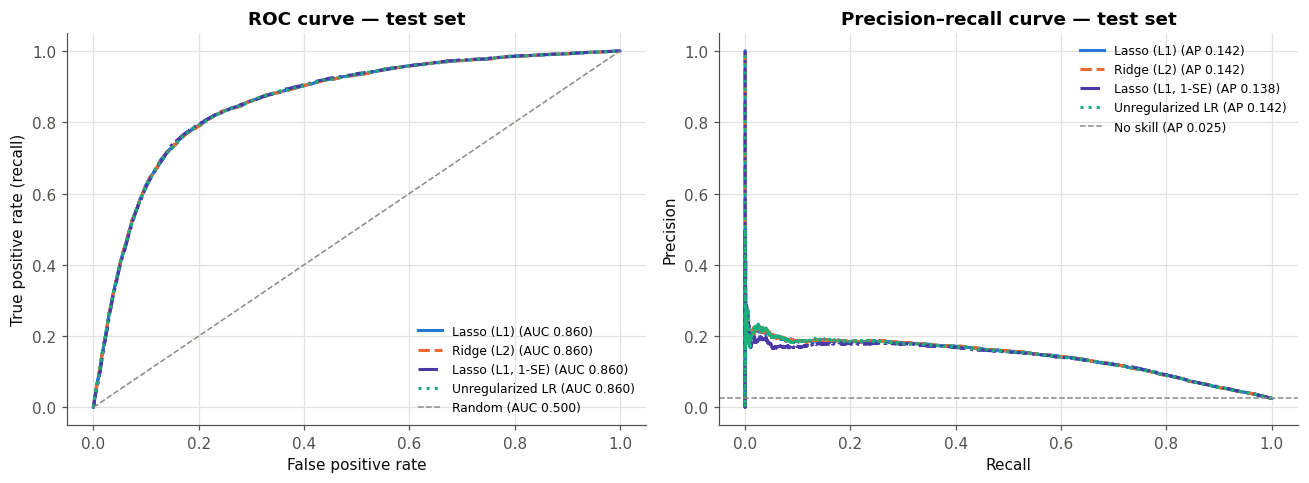

In [21]:
order = ["Lasso (L1)", "Ridge (L2)", "Lasso (L1, 1-SE)", "Unregularized LR"]
colors = {"Lasso (L1)": C_L1, "Ridge (L2)": C_L2, "Lasso (L1, 1-SE)": "#4a3aa7", "Unregularized LR": C_OLS}
styles = {"Lasso (L1)": "-", "Ridge (L2)": "--", "Lasso (L1, 1-SE)": "-.", "Unregularized LR": ":"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in order:
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    axes[0].plot(fpr, tpr, color=colors[name], ls=styles[name],
                 label=f"{name} (AUC {roc_auc_score(y_test, probas[name]):.3f})")
    pr, rc, _ = precision_recall_curve(y_test, probas[name])
    axes[1].plot(rc, pr, color=colors[name], ls=styles[name],
                 label=f"{name} (AP {average_precision_score(y_test, probas[name]):.3f})")
axes[0].plot([0, 1], [0, 1], color=C_BASE, lw=1, ls="--", label="Random (AUC 0.500)")
axes[1].axhline(y_test.mean(), color=C_BASE, lw=1, ls="--", label=f"No skill (AP {y_test.mean():.3f})")
axes[0].set(title="ROC curve — test set", xlabel="False positive rate", ylabel="True positive rate (recall)")
axes[1].set(title="Precision–recall curve — test set", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.legend(frameon=False, fontsize=8, loc="lower right" if ax is axes[0] else "upper right")
fig.tight_layout()
savefig(fig, "roc_pr_curves")

### 8.5 Inspect classification errors at the selected thresholds

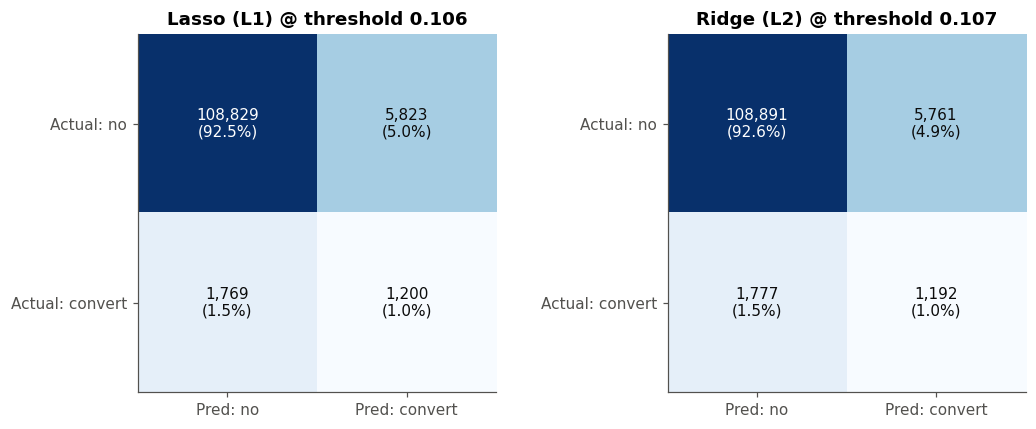

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ["Lasso (L1)", "Ridge (L2)"]):
    pred = (probas[name] >= thresholds[name]).astype(int)
    cm = confusion_matrix(y_test, pred)
    ax.imshow(cm, cmap="Blues", norm=plt.matplotlib.colors.LogNorm())
    ax.grid(False)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v:,}\n({v / cm.sum():.1%})", ha="center", va="center",
                color="white" if v > cm.max() / 3 else INK, fontsize=10)
    ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["Pred: no", "Pred: convert"],
           yticklabels=["Actual: no", "Actual: convert"],
           title=f"{name} @ threshold {thresholds[name]:.3f}")
fig.tight_layout()
savefig(fig, "confusion_matrices")

### 8.6 Assess retrospective ranking with cumulative gains

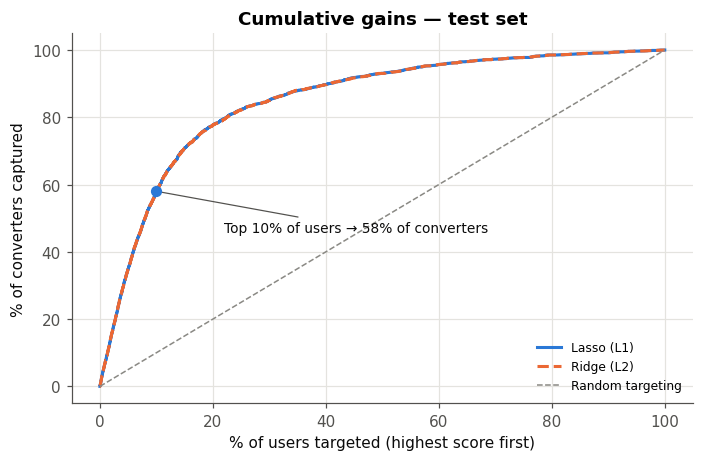

In [23]:
# Cumulative gains: share of all converters captured when targeting the top-k% of scored users
fig, ax = plt.subplots(figsize=(6.5, 4.3))
pct = np.linspace(0, 1, 101)
for name in ["Lasso (L1)", "Ridge (L2)"]:
    order_idx = np.argsort(-probas[name])
    cum = np.concatenate([[0], np.cumsum(y_test[order_idx]) / y_test.sum()])
    xs = np.linspace(0, 1, len(cum))
    ax.plot(xs * 100, cum * 100, color=colors[name], ls=styles[name], label=name)
ax.plot([0, 100], [0, 100], color=C_BASE, ls="--", lw=1, label="Random targeting")
cap10 = summary.loc["Lasso (L1)", "top10_capture"]
ax.scatter([10], [cap10 * 100], color=C_L1, s=40, zorder=5)
ax.annotate(f"Top 10% of users → {cap10:.0%} of converters", (10, cap10 * 100), xytext=(22, cap10 * 100 - 12),
            fontsize=9, color=INK, arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
ax.set(title="Cumulative gains — test set", xlabel="% of users targeted (highest score first)",
       ylabel="% of converters captured")
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
savefig(fig, "cumulative_gains")

### Observations from model evaluation

- **The models rank converters better than the constant baseline.** Tuned L1 achieves test ROC-AUC 0.8601 and AP 0.1420, compared with 0.5000 and approximately 0.0252 for the baseline.
- **Threshold choice changes the practical result.** At its training-selected threshold of 0.1064, tuned L1 has precision 17.09%, recall 40.42%, and F1 0.2402. It identifies more converters than at 0.50, but most positive predictions still correspond to non-conversions.
- **High accuracy is not sufficient here.** At 0.50, all fitted models have zero recall on the test set despite accuracy of about 97.48%.
- **The sparse model involves a measurable trade-off.** The 1-SE L1 fit retains 22 of 34 encoded coefficients. Its ROC-AUC rounds to 0.8601, while AP falls to 0.1378 from 0.1420 for tuned L1. Similar AUC therefore does not mean identical performance.
- **The ranking is concentrated.** The highest-scored approximately 10% of records contain 58.00% of observed test conversions for tuned L1. This does not establish profit or incremental advertising benefit.
- **The comparison remains exploratory.** The table gives point estimates for this split. No formal equivalence test, paired uncertainty interval, or external validation has been carried out.

## 9. Interpretation of Coefficients



### 9.1 Tabulate standardized coefficients and selected terms

In [24]:
coef_df = pd.DataFrame({name: models[name].named_steps["clf"].coef_.ravel()
                        for name in ["Ridge (L2)", "Lasso (L1)", "Lasso (L1, 1-SE)"]},
                       index=FEATURE_NAMES)
coef_df["Selected by Lasso 1-SE"] = coef_df["Lasso (L1, 1-SE)"].abs() > 1e-8
coef_df = coef_df.reindex(coef_df["Ridge (L2)"].abs().sort_values(ascending=False).index)
coef_df.to_csv(OUT_DIR / "coefficients.csv")
coef_df.round(4)

,Ridge (L2),Lasso (L1),"Lasso (L1, 1-SE)",Selected by Lasso 1-SE
log_total_ads,1.9597,1.9582,1.7823,True
total_ads,-0.2707,-0.2709,-0.2049,True
most_ads_hour_02,-0.1263,-0.1215,-0.0575,True
most_ads_day_Monday,0.1014,0.1163,0.0950,True
most_ads_hour_16,0.0870,0.0729,0.0578,True
is_ad,0.0815,0.0781,0.0452,True
most_ads_day_Tuesday,0.0792,0.0917,0.0682,True
most_ads_hour_01,-0.0754,-0.0744,-0.0307,True
most_ads_day_Saturday,-0.0749,-0.0569,-0.0338,True
most_ads_day_Friday,-0.0693,-0.0504,-0.0282,True


### 9.2 Compare Ridge and sparse L1 coefficients visually

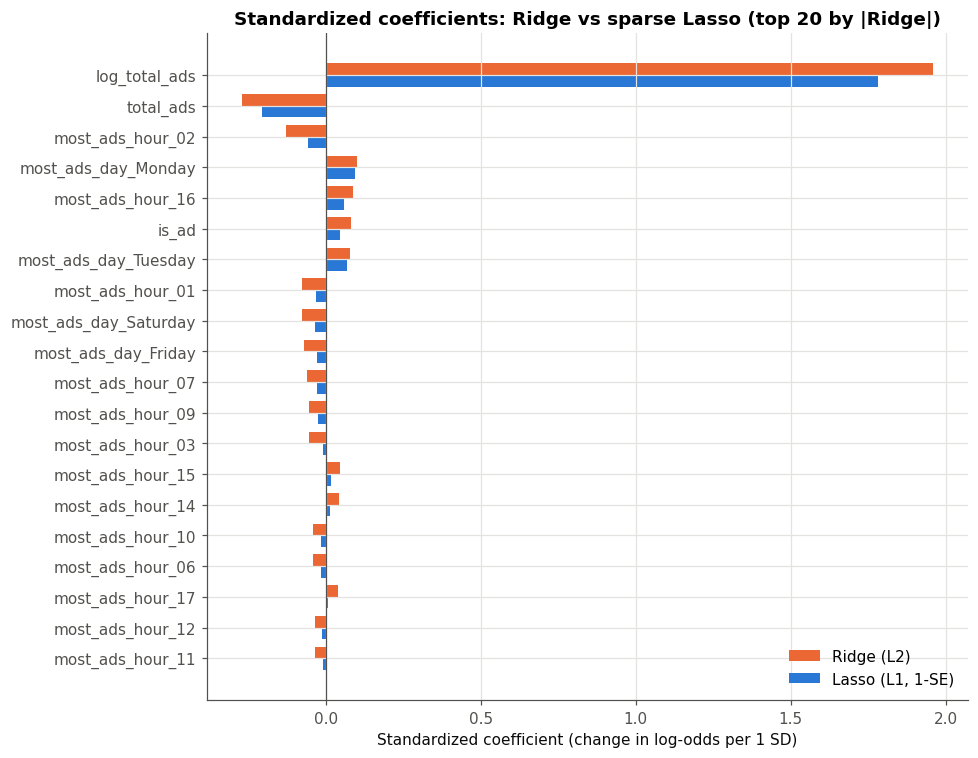

In [25]:
top = coef_df.head(20).iloc[::-1]
y_pos = np.arange(len(top))
h = 0.38
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(y_pos + h / 2, top["Ridge (L2)"], height=h, color=C_L2, label="Ridge (L2)")
ax.barh(y_pos - h / 2, top["Lasso (L1, 1-SE)"], height=h, color=C_L1, label="Lasso (L1, 1-SE)")
for i, (feat, row) in enumerate(top.iterrows()):
    if abs(row["Lasso (L1, 1-SE)"]) <= 1e-8:
        ax.text(0, i - h / 2, "  0 (dropped)", va="center", fontsize=7.5, color=INK2)
ax.set_yticks(y_pos, top.index)
ax.axvline(0, color=INK2, lw=0.8)
ax.set(title="Standardized coefficients: Ridge vs sparse Lasso (top 20 by |Ridge|)",
       xlabel="Standardized coefficient (change in log-odds per 1 SD)")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
savefig(fig, "coefficients_l1_vs_l2")

### 9.3 Identify excluded terms and quantify coefficient shrinkage

In [26]:
dropped_best = coef_df.index[coef_df["Lasso (L1)"].abs() <= 1e-8].tolist()
dropped_1se = coef_df.index[coef_df["Lasso (L1, 1-SE)"].abs() <= 1e-8].tolist()
print(f"Lasso (best C) dropped {len(dropped_best)} features: {dropped_best}\n")
print(f"Lasso (1-SE)   dropped {len(dropped_1se)} of {len(FEATURE_NAMES)} features: {dropped_1se}\n")

# Shrinkage relative to the least-regularized fit on the same encoding (C = 10, end of the path)
shrink = (coef_df[["Ridge (L2)", "Lasso (L1)", "Lasso (L1, 1-SE)"]].abs().sum()
          / path_l1.iloc[-1].abs().sum())
print(f"L1-norm of coefficients relative to the least-regularized fit (C = {PATH_C[-1]:g}):")
print(shrink.round(3).to_string())

Lasso (best C) dropped 2 features: ['most_ads_day_Sunday', 'most_ads_hour_19']

Lasso (1-SE)   dropped 12 of 34 features: ['most_ads_hour_22', 'most_ads_day_Thursday', 'most_ads_hour_04', 'most_ads_hour_20', 'most_ads_hour_00', 'most_ads_hour_21', 'most_ads_hour_23', 'most_ads_hour_18', 'most_ads_day_Sunday', 'most_ads_day_Wednesday', 'most_ads_hour_19', 'most_ads_hour_13']

L1-norm of coefficients relative to the least-regularized fit (C = 10):
Ridge (L2)         0.9910
Lasso (L1)         0.9570
Lasso (L1, 1-SE)   0.6900


**Observations from the coefficient comparison**

- The tuned L1 and L2 fits both include the raw and logarithmic exposure terms. Their joint contribution permits a nonlinear relationship with conversion. The signs do not establish diminishing economic returns or an optimal number of ads.
- In this fit, Ridge retains all 34 encoded coefficients, tuned L1 retains 32, and the 1-SE L1 candidate retains 22. The sparse candidate therefore requires fewer nonzero terms, although it still relies on the same original predictor types.
- Selection depends on the penalty and encoding. A discarded day or hour indicator should not be interpreted as statistically unimportant; correlated and redundant columns can affect which coefficients L1 retains.
- I do not give the adjusted ad-group coefficient a causal interpretation. Even with randomized assignment, controlling for exposure or timing measured after assignment could bias an estimate of the total treatment effect.
- The useful interpretation is a sparsity-performance comparison for this dataset. Establishing stable feature importance would require further work, such as repeated resampling or a suitable held-out importance analysis.

**What interpretability means here.** A shorter coefficient list makes the fitted rule easier to inspect, but the sparse model still includes day and hour information through its remaining indicators. Dropping individual encoded columns is not equivalent to removing the original variable. Nor does a large standardized coefficient prove that a predictor would remain important under a different encoding or correlated feature set. I therefore report selection counts and coefficient values as properties of the fitted models, while reserving stronger importance claims for a stability or held-out importance study.

### 9.4 Export results and reproducibility metadata

In [27]:
payload = {
    "dataset_sha256": hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    "provenance_status": "Original empirical collection and hosted-file identity unverified",
    "metric_definitions": {"pr_auc": "average_precision_score (not trapezoidal PR-AUC)"},
    "versions": {p: version(p) for p in ["pandas", "numpy", "scikit-learn", "matplotlib", "joblib", "nbformat", "nbclient", "ipykernel"]},
    "n_rows": int(len(df)), "n_train": int(len(X_train)), "n_test": int(len(X_test)),
    "base_rate": float(base_rate), "n_features": len(FEATURE_NAMES), "n_features_ref": N_REF,
    "group_rates": grp["rate"].to_dict(), "ad_vs_psa_lift": float(lift),
    "best_C": {k: float(v) for k, v in BEST_C.items()},
    "cv_best_auc": {"l1": float(searches["l1"].best_score_), "l2": float(searches["l2"].best_score_)},
    "thresholds": thresholds,
    "nonzero": {name: int((coef_df[name].abs() > 1e-8).sum())
                for name in ["Ridge (L2)", "Lasso (L1)", "Lasso (L1, 1-SE)"]},
    "dropped_l1_best": dropped_best, "dropped_l1_1se": dropped_1se,
    "coef_norm_ratio": shrink.to_dict(),
    "test_metrics": results.to_dict(orient="records"),
}
(OUT_DIR / "metrics.json").write_text(json.dumps(payload, indent=2, default=float))
results.to_csv(OUT_DIR / "test_metrics.csv", index=False)
cv_l1.merge(cv_l2, on="C", suffixes=("_L1", "_L2")).to_csv(OUT_DIR / "cv_results.csv", index=False)
print("Saved:", sorted(p.name for p in OUT_DIR.iterdir()))

Saved: ['coefficients.csv', 'cv_results.csv', 'metrics.json', 'test_metrics.csv']


## 10. Final Insight

- The clearest contribution of regularization in this analysis is the option to simplify the coefficient representation. The 1-SE L1 candidate uses 22 nonzero terms instead of 34, while retaining a similar ROC-AUC point estimate.
- That simplification is not free: average precision is lower for the sparse candidate. I would therefore choose between the models using the intended decision task rather than ROC-AUC alone.
- The results describe prediction within the supplied records. They do not establish that changing advertising exposure will cause additional purchases, or that the model is ready for a future campaign.

## 11. Recommendations

- Resolve the data-collection requirement before submission: obtain a documented dataset with demographics and purchase history, or secure the instructor's acceptance of the present exposure-only scope. Do not invent missing customer attributes or join unrelated customers across datasets.
- Obtain documentation of the source, collection process, and outcome window before presenting the records as verified empirical data.
- Define when a prediction would be made and use only information available at that time. Campaign-total exposure may not be available before a conversion decision.
- Evaluate a fixed modeling procedure on a new campaign or an untouched holdout, then assess calibration, uncertainty in performance differences, and selection stability.
- Choose a deployment threshold using measured costs, conversion value, and capacity. The F1-selected threshold in this project is an analytical comparison, not an established business optimum.

## 12. Conclusion
This project demonstrates a complete computational workflow for comparing regularized logistic regression models on the supplied marketing records. Tuned L1 achieves a test ROC-AUC of 0.8601 and AP of 0.1420. A stronger L1 penalty yields a sparser model with similar ROC-AUC but lower AP, illustrating why interpretability and performance should be considered together.

The conclusions remain limited by the data and validation design. The source's original empirical authenticity is unverified, exposure timing is unclear, and the full-data exploratory analysis limits the independence of the test evaluation. The dataset also lacks the demographics and purchase history specified in the assignment. These limitations do not erase the modeling results, but they prevent a claim that every assignment requirement has been satisfied.

## 13. References

faviovaz. (n.d.). *Marketing A/B testing* [Data set]. Kaggle. [https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing)

Joblib. (n.d.). *Joblib documentation*. Retrieved October 1, 2026, from [https://joblib.readthedocs.io/en/stable/](https://joblib.readthedocs.io/en/stable/)

Matplotlib. (n.d.). *Matplotlib documentation*. Retrieved October 1, 2026, from [https://matplotlib.org/stable/](https://matplotlib.org/stable/)

NumPy. (n.d.). *NumPy documentation*. Retrieved October 1, 2026, from [https://numpy.org/doc/](https://numpy.org/doc/)

pandas. (n.d.). *pandas documentation*. Retrieved October 1, 2026, from [https://pandas.pydata.org/docs/](https://pandas.pydata.org/docs/)

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. [https://www.jmlr.org/papers/v12/pedregosa11a.html](https://www.jmlr.org/papers/v12/pedregosa11a.html)

Project Jupyter. (n.d.). *Project Jupyter documentation*. Retrieved October 1, 2026, from [https://docs.jupyter.org/en/latest/](https://docs.jupyter.org/en/latest/)

python-docx. (n.d.). *python-docx documentation*. Retrieved October 1, 2026, from [https://python-docx.readthedocs.io/en/latest/](https://python-docx.readthedocs.io/en/latest/)

Python Software Foundation. (n.d.). *Python 3.11 documentation*. Retrieved October 1, 2026, from [https://docs.python.org/3.11/index.html](https://docs.python.org/3.11/index.html)

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), Article e0118432. [https://doi.org/10.1371/journal.pone.0118432](https://doi.org/10.1371/journal.pone.0118432)

scikit-learn. (n.d.-a). *average_precision_score*. In Scikit-learn 1.7 documentation. [https://scikit-learn.org/1.7/modules/generated/sklearn.metrics.average_precision_score.html](https://scikit-learn.org/1.7/modules/generated/sklearn.metrics.average_precision_score.html)

scikit-learn. (n.d.-b). *LogisticRegression*. In Scikit-learn 1.7 documentation. [https://scikit-learn.org/1.7/modules/generated/sklearn.linear_model.LogisticRegression.html](https://scikit-learn.org/1.7/modules/generated/sklearn.linear_model.LogisticRegression.html)